In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
df = pd.read_csv("../data/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1.0,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0.0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0.0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0.0,159,0,0.0,2,0,2,1


In [2]:
duplicates_count = df.duplicated().sum()
print(df.duplicated())
print(duplicates_count)

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool
720


In [3]:
if duplicates_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found.")

Duplicates removed.


In [4]:
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())


C:\Users\Lenovo - LOQ\AppData\Local\Temp\ipykernel_13540\1278593864.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].median())


In [6]:
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
outlier_cols = []

for col in df.select_dtypes(include=["int64", "float64"]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if ((df[col] < lower) | (df[col] > upper)).any():
        outlier_cols.append(col)

print("Outlier columns:", outlier_cols)


Outlier columns: ['trestbps', 'chol', 'fbs', 'thalach', 'oldpeak', 'ca', 'thal']


In [8]:
outlier_cols = ['trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']

data_cleaned = df.copy()


In [9]:

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {outliers.shape[0]} outliers")

trestbps: 9 outliers
chol: 5 outliers
thalach: 1 outliers
oldpeak: 5 outliers
ca: 24 outliers
thal: 2 outliers


In [10]:
while True:
    old_rows = data_cleaned.shape[0]

    for col in outlier_cols:
        Q1 = data_cleaned[col].quantile(0.25)
        Q3 = data_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data_cleaned = data_cleaned[
            (data_cleaned[col] >= lower) & (data_cleaned[col] <= upper)
        ]

    new_rows = data_cleaned.shape[0]

    if old_rows == new_rows:
        break

In [11]:
for col in outlier_cols:
    Q1 = data_cleaned[col].quantile(0.25)
    Q3 = data_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data_cleaned[
        (data_cleaned[col] < lower) | (data_cleaned[col] > upper)
    ]

    print(f"{col}: {outliers.shape[0]} outliers remaining")

trestbps: 0 outliers remaining
chol: 0 outliers remaining
thalach: 0 outliers remaining
oldpeak: 0 outliers remaining
ca: 0 outliers remaining
thal: 0 outliers remaining


In [12]:
data_cleaned.to_csv("../data/cleaned_data_for_expert.csv", index=False)

In [13]:
data = pd.read_csv("../data/cleaned_data_for_expert.csv")
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000
mean,53.750958,0.689655,1.003831,129.183908,241.505747,0.126437,0.536398,151.406130,0.314176,0.960153,1.429119,0.509579,2.295019,0.578544
std,9.024073,0.463524,1.043287,15.133912,43.671291,0.332979,0.514797,21.901436,0.465079,1.043525,0.607450,0.721180,0.576073,0.494741
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,46.000000,0.000000,0.000000,120.000000,209.000000,0.000000,0.000000,138.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,239.000000,0.000000,1.000000,155.000000,0.000000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,269.000000,0.000000,1.000000,168.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,76.000000,1.000000,3.000000,170.000000,354.000000,1.000000,2.000000,202.000000,1.000000,4.000000,2.000000,2.000000,3.000000,1.000000


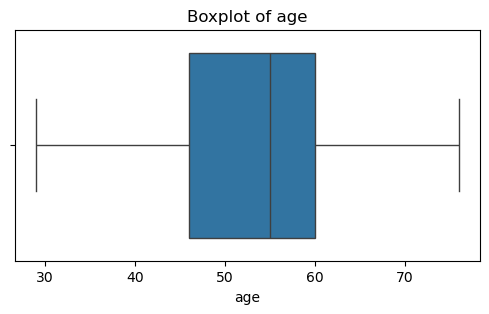

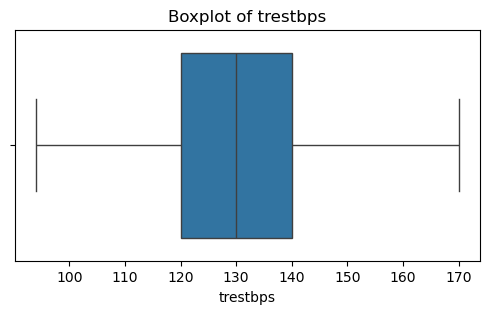

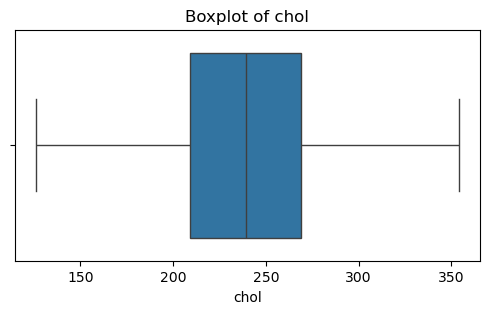

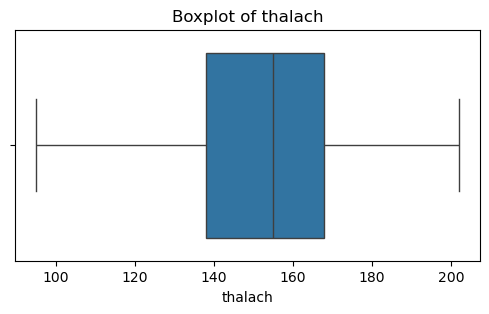

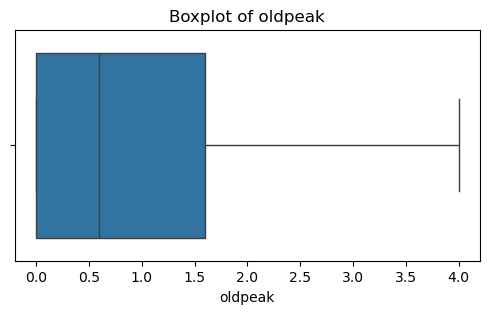

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in selected_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [15]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000
mean,53.750958,0.689655,1.003831,129.183908,241.505747,0.126437,0.536398,151.406130,0.314176,0.960153,1.429119,0.509579,2.295019,0.578544
std,9.024073,0.463524,1.043287,15.133912,43.671291,0.332979,0.514797,21.901436,0.465079,1.043525,0.607450,0.721180,0.576073,0.494741
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,46.000000,0.000000,0.000000,120.000000,209.000000,0.000000,0.000000,138.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,239.000000,0.000000,1.000000,155.000000,0.000000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,269.000000,0.000000,1.000000,168.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,76.000000,1.000000,3.000000,170.000000,354.000000,1.000000,2.000000,202.000000,1.000000,4.000000,2.000000,2.000000,3.000000,1.000000


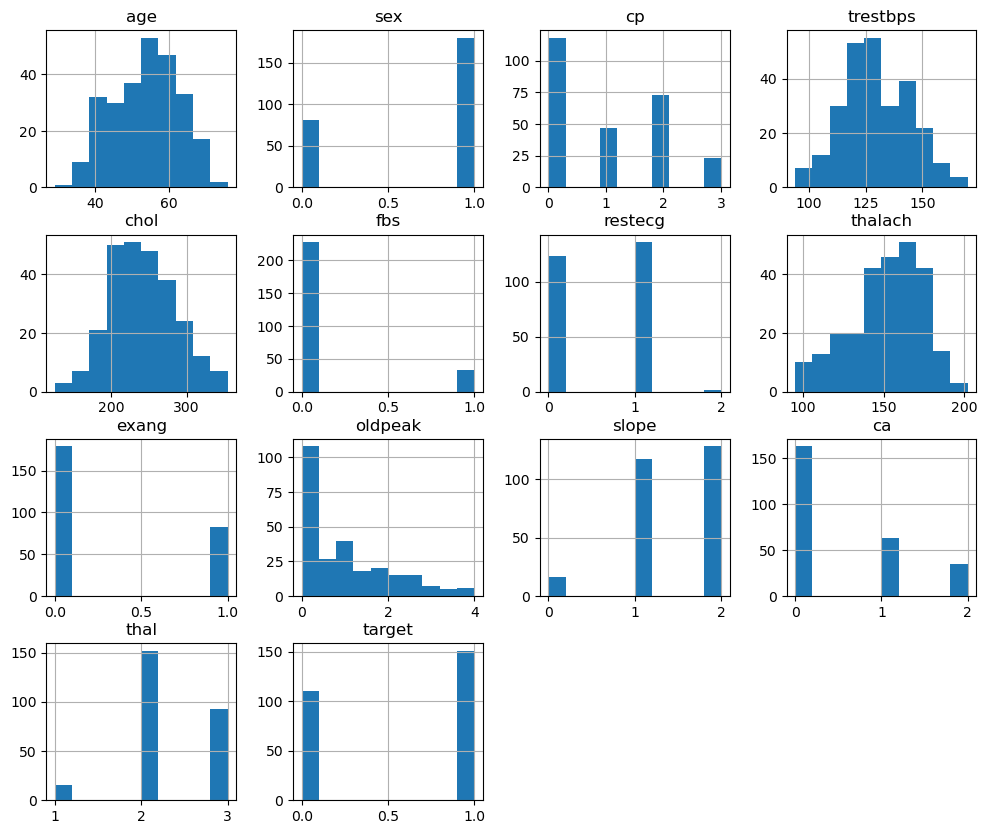

In [16]:
import matplotlib.pyplot as plt

data.hist(figsize=(12,10))
plt.show()

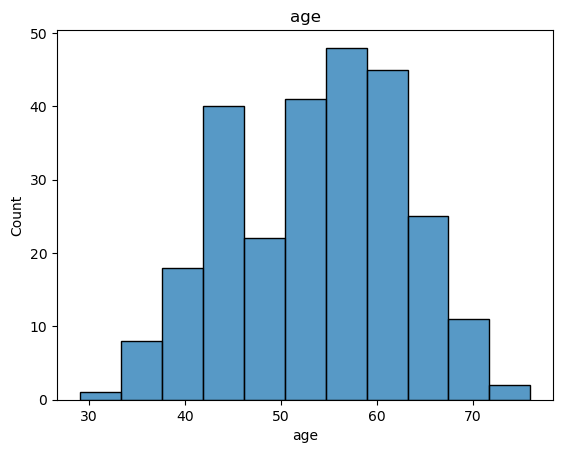

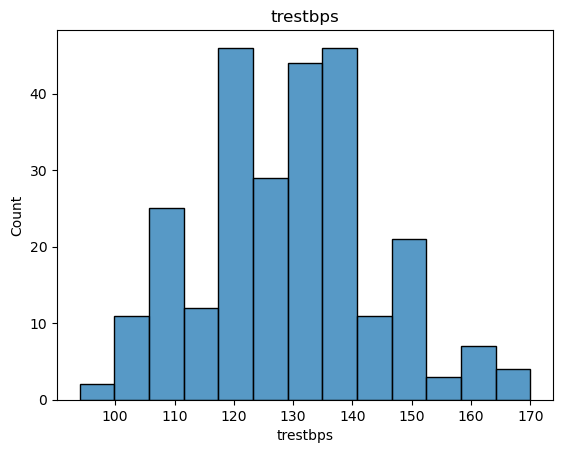

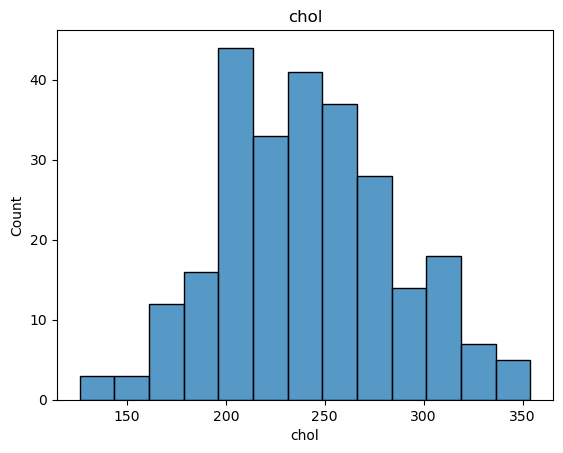

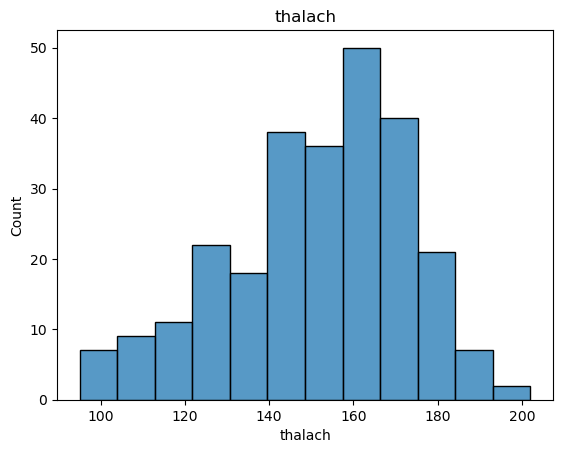

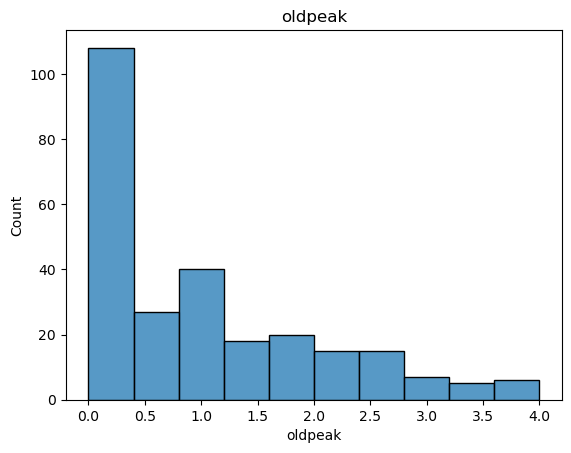

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in cols:
    sns.histplot(data[col])
    plt.title(col)
    plt.show()

In [18]:
corr_matrix = data.corr()

target_corr = corr_matrix['target'].sort_values(ascending=False)

print(target_corr)


target      1.000000
thalach     0.392822
cp          0.383168
slope       0.309748
restecg     0.151070
fbs        -0.002147
trestbps   -0.077962
chol       -0.098863
age        -0.204511
sex        -0.320976
thal       -0.398748
exang      -0.425255
oldpeak    -0.442394
ca         -0.462947
Name: target, dtype: float64


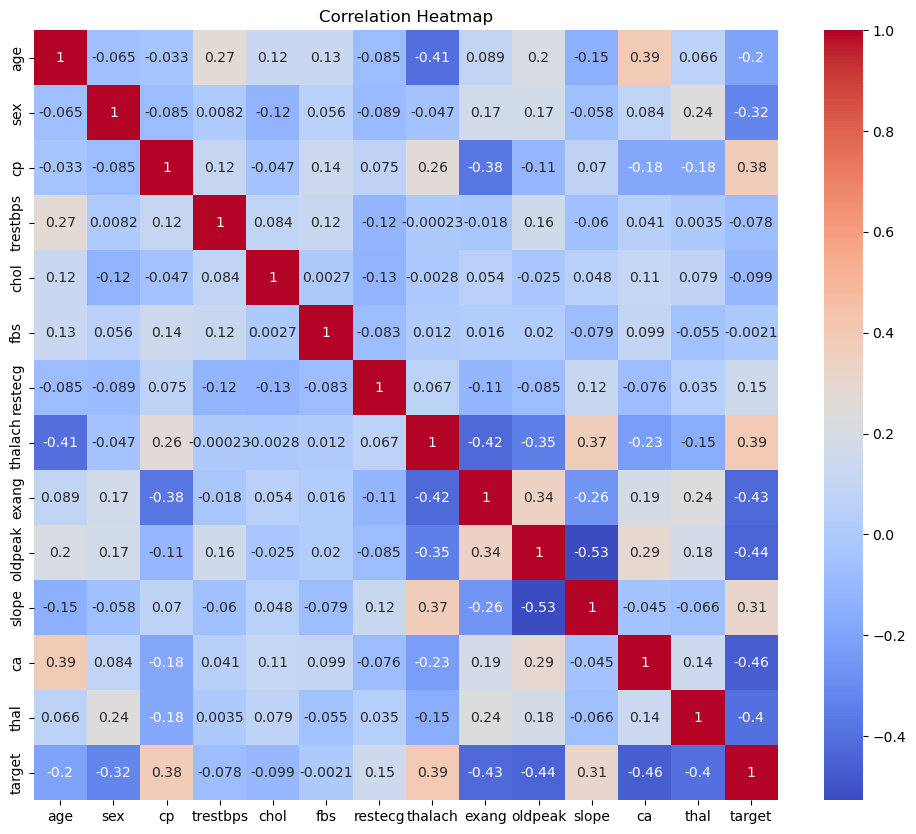

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [20]:
important_features = target_corr[abs(target_corr) > 0.2].index

if 'target' not in important_features:
    important_features = important_features.append(pd.Index(['target']))

data_f = data[important_features]
data_f

,target,thalach,cp,slope,age,sex,thal,exang,oldpeak,ca
0,0,168,0,2,52,1,3,0,1.0,2
1,0,155,0,0,53,1,3,1,3.1,0
2,0,125,0,0,70,1,3,1,2.6,0
3,0,161,0,2,61,1,3,0,0.0,1
4,1,122,0,1,58,0,2,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...
256,1,175,2,1,44,0,2,0,0.6,0
257,0,161,0,2,52,1,3,1,0.0,1
258,0,125,3,2,59,1,2,0,0.0,0
259,1,148,0,1,57,1,1,0,0.4,0


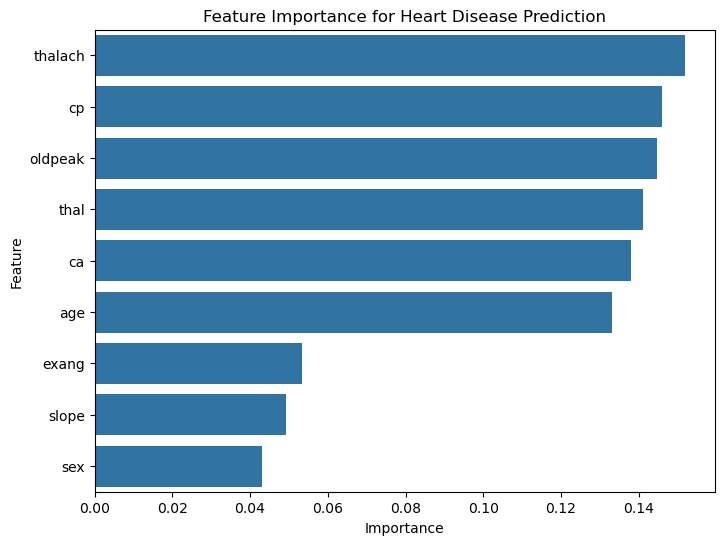

In [21]:
from sklearn.ensemble import RandomForestClassifier

X = data_f.drop('target', axis=1)
y = data_f['target']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance for Heart Disease Prediction')
plt.show()

In [22]:
from sklearn.preprocessing import MinMaxScaler

num_cols = data.select_dtypes(include=['int64', 'float64']).columns

num_cols = num_cols.drop('target')

scaler = MinMaxScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.489362,1.0,0.0,0.407895,0.377193,0.0,0.5,0.682243,0.0,0.250,1.0,1.0,1.0,0
1,0.510638,1.0,0.0,0.605263,0.337719,1.0,0.0,0.560748,1.0,0.775,0.0,0.0,1.0,0
2,0.872340,1.0,0.0,0.671053,0.210526,0.0,0.5,0.280374,1.0,0.650,0.0,0.0,1.0,0
3,0.680851,1.0,0.0,0.710526,0.337719,0.0,0.5,0.616822,0.0,0.000,1.0,0.5,1.0,0
4,0.617021,0.0,0.0,0.078947,0.535088,0.0,0.0,0.252336,0.0,0.250,0.5,0.0,0.5,1


In [23]:
cat_cols = data.select_dtypes(include=['object']).columns

data = pd.get_dummies(data, columns=cat_cols)

In [24]:
print("Final shape:", data.shape)
print(data.head())

Final shape: (261, 14)
        age  sex   cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.489362  1.0  0.0  0.407895  0.377193  0.0      0.5  0.682243    0.0   
1  0.510638  1.0  0.0  0.605263  0.337719  1.0      0.0  0.560748    1.0   
2  0.872340  1.0  0.0  0.671053  0.210526  0.0      0.5  0.280374    1.0   
3  0.680851  1.0  0.0  0.710526  0.337719  0.0      0.5  0.616822    0.0   
4  0.617021  0.0  0.0  0.078947  0.535088  0.0      0.0  0.252336    0.0   

   oldpeak  slope   ca  thal  target  
0    0.250    1.0  1.0   1.0       0  
1    0.775    0.0  0.0   1.0       0  
2    0.650    0.0  0.0   1.0       0  
3    0.000    1.0  0.5   1.0       0  
4    0.250    0.5  0.0   0.5       1  


In [25]:
data.to_csv("../data/cleaned_data_for_ml.csv", index=False)